# Caso 5 - Canibalizacion de Negocio (Prediccion de Riesgo Territorial)

---

## Problema
Abrir una nueva sucursal demasiado cerca de una existente puede quitarle clientes a la propia empresa en lugar de captarlos del mercado. Este fenomeno se llama canibalizacion y erosiona el EBITDA sin que la gerencia lo perciba a tiempo.

## Pregunta de Negocio
> **"Si abro una nueva sucursal a X kilometros de distancia, con Y diferencia de precios y Z porcentaje de publico compartido, cuanto riesgo de canibalizacion estoy generando?"**

## Objetivo
- Cuantificar el riesgo de canibalizacion (0-100%) de forma continua y fluida.
- Identificar los tres drivers principales: distancia, diferencia de precio y publico compartido.
- Proveer un simulador "What-If" para que Expansiones tome decisiones basadas en datos.

## Propuesta Tecnica
- Competencia de modelos de Regresion Continua: XGBoost, GradientBoosting, RandomForest, Ridge.
- Analisis de sensibilidad: como varia el riesgo al mover cada variable independientemente.
- Feature Importance para cuantificar el peso de cada driver territorial.

## Dataset
Fuente primaria: `TRAINING_DATASETS.OBT_CANNIBALIZATION_PREDICTION`
Failover: Dataset sintetico algoritmico de 100,000 registros basado en heuristicas de negocio validadas.
Features: `DISTANCIA_KM`, `DIFERENCIA_PRECIO`, `PUBLICO_COMPARTIDO`
Target: `RIESGO_CANIBALIZACION` (0 a 100%)

---

## 1. Setup y Conexion

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import snowflake.connector
from dotenv import load_dotenv
import mlflow, mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

load_dotenv()
mlflow.set_tracking_uri("sqlite:///mlflow.db")
print('[OK] Entorno configurado. MLflow -> sqlite:///mlflow.db')

[OK] Entorno configurado. MLflow -> sqlite:///mlflow.db


In [2]:
conn = None
df = None

try:
    conn = snowflake.connector.connect(
        user=os.getenv('SNOWFLAKE_USER'),
        password=os.getenv('SNOWFLAKE_PASSWORD'),
        account=os.getenv('SNOWFLAKE_ACCOUNT'),
        warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
        database=os.getenv('SNOWFLAKE_DATABASE'),
        schema='TRAINING_DATASETS'
    )
    try:
        df = pd.read_sql(
            'SELECT DISTANCIA_KM, DIFERENCIA_PRECIO, PUBLICO_COMPARTIDO, RIESGO_CANIBALIZACION '
            'FROM TRAINING_DATASETS.OBT_CANNIBALIZATION_PREDICTION', conn)
        print(f'[Snowflake] Datos cargados: {len(df):,} filas')
    except Exception as e1:
        print(f'[Snowflake] Tabla no encontrada: {e1}')
        df = None
except Exception as e:
    print(f'[Snowflake] Conexion fallida: {e}')

if df is None or len(df) == 0:
    print('[FAILOVER] Generando dataset sintetico algoritmico de 100,000 registros...')
    np.random.seed(42)
    n = 100000
    dist_km      = np.random.uniform(0.0, 20.0, n)
    dif_precio   = np.random.uniform(0.0, 50.0, n)
    pub_comp     = np.random.uniform(0.0, 100.0, n)

    # Heuristica fluida monotonica (la misma logica que usa el modelo en produccion)
    pen_dist  = np.maximum(0, 45.0 * (1.0 - (dist_km / 15.0)))
    pen_prec  = np.where(dif_precio < 20.0,
                         20.0 * (1.0 - (dif_precio / 20.0)),
                         -15.0 * ((dif_precio - 20) / 30.0))
    pen_pub   = 35.0 * (pub_comp / 100.0)
    riesgo    = np.clip(10.0 + pen_dist + pen_prec + pen_pub + np.random.normal(0, 1.5, n), 0, 100)

    df = pd.DataFrame({
        'DISTANCIA_KM': dist_km,
        'DIFERENCIA_PRECIO': dif_precio,
        'PUBLICO_COMPARTIDO': pub_comp,
        'RIESGO_CANIBALIZACION': riesgo
    })
    print(f'[FAILOVER] Dataset sintetico generado: {len(df):,} filas')

df.columns = [c.upper() for c in df.columns]
print(f'\nResumen del Target (RIESGO_CANIBALIZACION):')
print(df['RIESGO_CANIBALIZACION'].describe().round(2))

[Snowflake] Tabla no encontrada: Execution failed on sql 'SELECT DISTANCIA_KM, DIFERENCIA_PRECIO, PUBLICO_COMPARTIDO, RIESGO_CANIBALIZACION FROM TRAINING_DATASETS.OBT_CANNIBALIZATION_PREDICTION': 002003 (42S02): SQL compilation error:
Object 'HGC_DW.TRAINING_DATASETS.OBT_CANNIBALIZATION_PREDICTION' does not exist or not authorized.
[FAILOVER] Generando dataset sintetico algoritmico de 100,000 registros...
[FAILOVER] Dataset sintetico generado: 100,000 filas

Resumen del Target (RIESGO_CANIBALIZACION):
count    100000.00
mean         43.86
std          20.59
min           0.00
25%          28.77
50%          42.99
75%          58.42
max         100.00
Name: RIESGO_CANIBALIZACION, dtype: float64


## 2. EDA - Exploracion y Distribucion del Riesgo

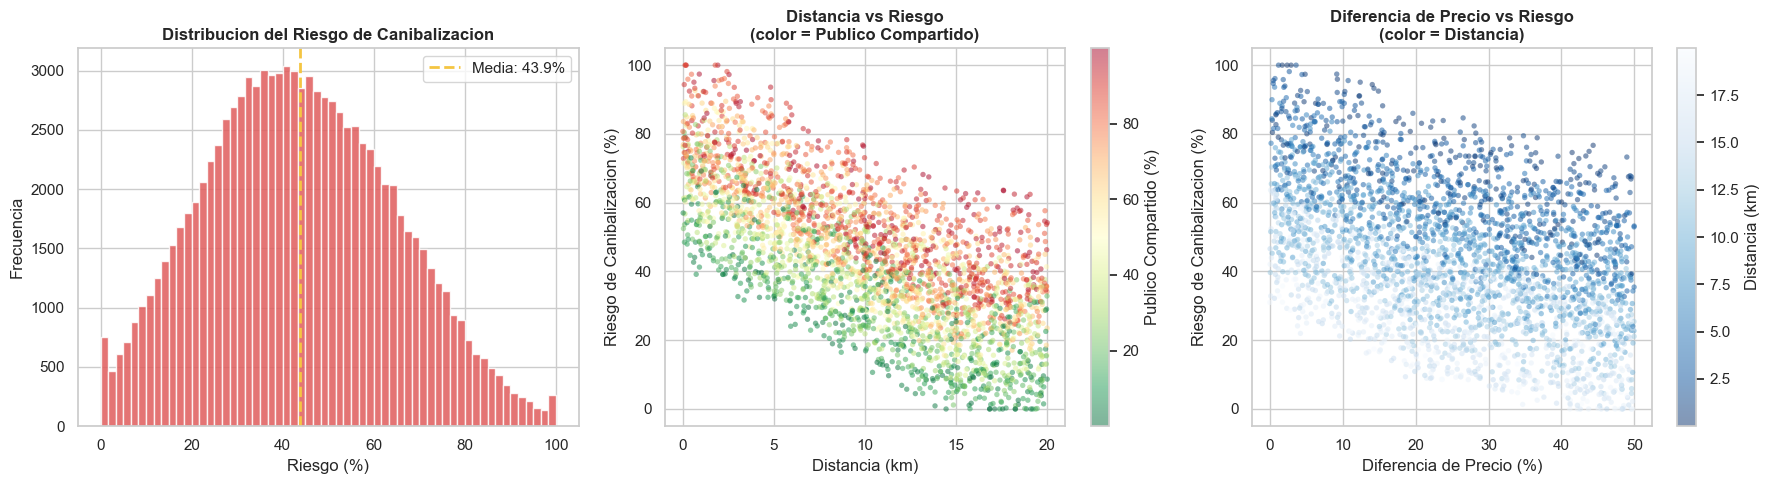

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribucion del riesgo
axes[0].hist(df['RIESGO_CANIBALIZACION'], bins=60,
             color='#E05C5C', edgecolor='white', alpha=0.85)
axes[0].axvline(df['RIESGO_CANIBALIZACION'].mean(), color='#F4C542',
                linestyle='--', linewidth=2, label=f'Media: {df["RIESGO_CANIBALIZACION"].mean():.1f}%')
axes[0].set_title('Distribucion del Riesgo de Canibalizacion', fontweight='bold')
axes[0].set_xlabel('Riesgo (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Distancia vs Riesgo (muestra)
sample = df.sample(min(3000, len(df)), random_state=42)
sc = axes[1].scatter(sample['DISTANCIA_KM'], sample['RIESGO_CANIBALIZACION'],
                     c=sample['PUBLICO_COMPARTIDO'], cmap='RdYlGn_r',
                     alpha=0.5, s=15, edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='Publico Compartido (%)')
axes[1].set_title('Distancia vs Riesgo\n(color = Publico Compartido)', fontweight='bold')
axes[1].set_xlabel('Distancia (km)')
axes[1].set_ylabel('Riesgo de Canibalizacion (%)')

# Diferencia de Precio vs Riesgo
sc2 = axes[2].scatter(sample['DIFERENCIA_PRECIO'], sample['RIESGO_CANIBALIZACION'],
                      c=sample['DISTANCIA_KM'], cmap='Blues_r',
                      alpha=0.5, s=15, edgecolors='none')
plt.colorbar(sc2, ax=axes[2], label='Distancia (km)')
axes[2].set_title('Diferencia de Precio vs Riesgo\n(color = Distancia)', fontweight='bold')
axes[2].set_xlabel('Diferencia de Precio (%)')
axes[2].set_ylabel('Riesgo de Canibalizacion (%)')

plt.tight_layout()
plt.savefig('cannib_eda.png', dpi=150, bbox_inches='tight')
plt.show()

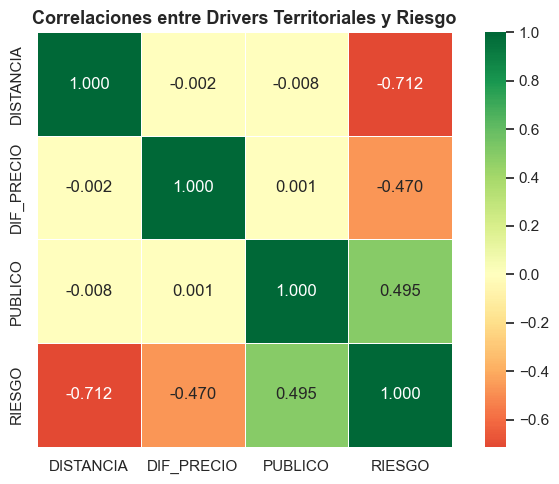


Correlacion con RIESGO_CANIBALIZACION:
   PUBLICO_COMPARTIDO        -> +0.4955
   DIFERENCIA_PRECIO         -> -0.4704
   DISTANCIA_KM              -> -0.7118


In [4]:
corr = df[['DISTANCIA_KM','DIFERENCIA_PRECIO','PUBLICO_COMPARTIDO','RIESGO_CANIBALIZACION']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5,
            xticklabels=['DISTANCIA','DIF_PRECIO','PUBLICO','RIESGO'],
            yticklabels=['DISTANCIA','DIF_PRECIO','PUBLICO','RIESGO'])
plt.title('Correlaciones entre Drivers Territoriales y Riesgo', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cannib_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelacion con RIESGO_CANIBALIZACION:')
corr_t = corr['RIESGO_CANIBALIZACION'].drop('RIESGO_CANIBALIZACION').sort_values(ascending=False)
for feat, val in corr_t.items():
    print(f'   {feat:<25} -> {val:+.4f}')

## 3. Competencia de Modelos de Regresion

In [5]:
FEAT_COLS = ['DISTANCIA_KM', 'DIFERENCIA_PRECIO', 'PUBLICO_COMPARTIDO']
TARGET    = 'RIESGO_CANIBALIZACION'

X = df[FEAT_COLS].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([('num', StandardScaler(), FEAT_COLS)])

MODELS = {
    "LinearRegression":  LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "RandomForest":      RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    "GradientBoosting":  GradientBoostingRegressor(n_estimators=100, max_depth=6, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42),
}

mlflow.set_experiment("HGC_Cannibalization_Notebook_Caso5")

resultados = {}
print(f"{'Modelo':<22} {'R2':>8} {'RMSE (%)':>10} {'MAE (%)':>10}")
print("-" * 55)

for nombre, modelo in MODELS.items():
    with mlflow.start_run(run_name=nombre):
        pipeline = Pipeline([('pre', preprocessor), ('reg', modelo)])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        r2   = r2_score(y_test, y_pred)
        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mlflow.log_metrics({'r2': r2, 'mae': mae, 'rmse': rmse})
        resultados[nombre] = {'pipeline': pipeline, 'r2': r2, 'mae': mae, 'rmse': rmse}
        print(f"  {nombre:<20} {r2:>8.4f} {rmse:>10.2f} {mae:>10.2f}")

campeon_nombre = max(resultados, key=lambda m: resultados[m]['r2'])
campeon = resultados[campeon_nombre]
print(f"\nCAMPEON: {campeon_nombre}  (R2={campeon['r2']:.4f}, MAE={campeon['mae']:.2f}%)")

2026/04/21 15:50:22 INFO mlflow.tracking.fluent: Experiment with name 'HGC_Cannibalization_Notebook_Caso5' does not exist. Creating a new experiment.


Modelo                       R2   RMSE (%)    MAE (%)
-------------------------------------------------------


  LinearRegression       0.9694       3.60       2.87
  Ridge                  0.9694       3.60       2.87


  RandomForest           0.9850       2.52       2.01


  GradientBoosting       0.9941       1.59       1.26


  XGBoost                0.9941       1.58       1.26

CAMPEON: XGBoost  (R2=0.9941, MAE=1.26%)


## 4. Feature Importance - Drivers del Riesgo Territorial

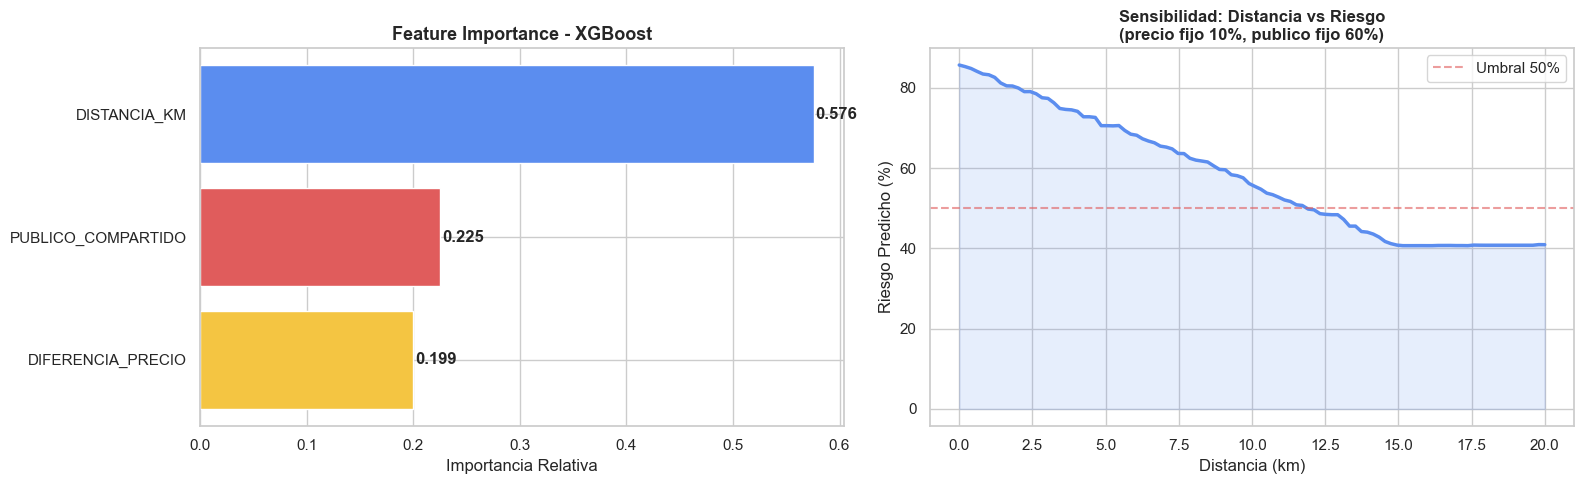

In [6]:
try:
    reg_model = campeon['pipeline'].named_steps['reg']
    if hasattr(reg_model, 'feature_importances_'):
        importances = reg_model.feature_importances_
    elif hasattr(reg_model, 'coef_'):
        importances = np.abs(reg_model.coef_)
    else:
        importances = None

    if importances is not None:
        fi_df = pd.DataFrame({'feature': FEAT_COLS, 'importance': importances})
        fi_df = fi_df.sort_values('importance', ascending=True)

        color_map = {'DISTANCIA_KM': '#5B8DEF', 'DIFERENCIA_PRECIO': '#F4C542', 'PUBLICO_COMPARTIDO': '#E05C5C'}
        colores_fi = [color_map.get(f, '#888') for f in fi_df['feature']]

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        axes[0].barh(fi_df['feature'], fi_df['importance'], color=colores_fi, edgecolor='white')
        axes[0].set_title(f'Feature Importance - {campeon_nombre}', fontweight='bold', fontsize=13)
        axes[0].set_xlabel('Importancia Relativa')
        for i, (val, feat) in enumerate(zip(fi_df['importance'], fi_df['feature'])):
            axes[0].text(val + 0.002, i, f'{val:.3f}', va='center', fontweight='bold')

        # Sensibilidad: como varia el riesgo al mover Distancia de 0 a 20 km
        dist_range = np.linspace(0, 20, 100)
        riesgo_vs_dist = campeon['pipeline'].predict(
            pd.DataFrame({'DISTANCIA_KM': dist_range,
                          'DIFERENCIA_PRECIO': [10]*100,
                          'PUBLICO_COMPARTIDO': [60]*100}))
        axes[1].plot(dist_range, riesgo_vs_dist, color='#5B8DEF', linewidth=2.5)
        axes[1].fill_between(dist_range, riesgo_vs_dist, alpha=0.15, color='#5B8DEF')
        axes[1].set_title('Sensibilidad: Distancia vs Riesgo\n(precio fijo 10%, publico fijo 60%)', fontweight='bold')
        axes[1].set_xlabel('Distancia (km)')
        axes[1].set_ylabel('Riesgo Predicho (%)')
        axes[1].axhline(50, color='#E05C5C', linestyle='--', alpha=0.6, label='Umbral 50%')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig('cannib_importance_sensitivity.png', dpi=150, bbox_inches='tight')
        plt.show()
except Exception as e:
    print(f'Feature Importance no disponible: {e}')

## 5. Mapa de Riesgo Territorial (Distancia x Publico Compartido)

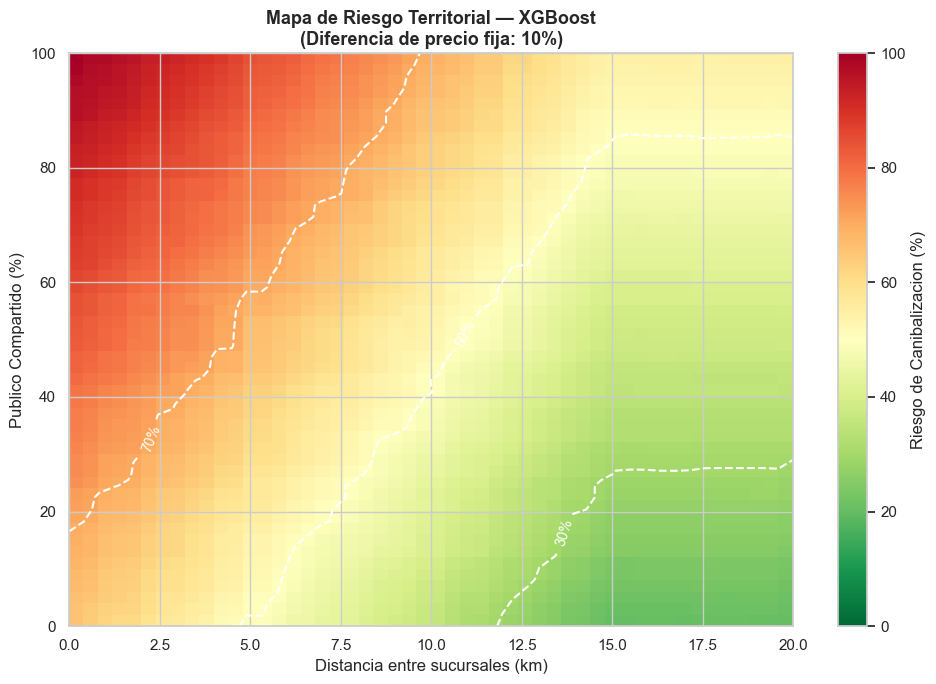

Verde = bajo riesgo | Rojo = alta canibalizacion


In [7]:
# Heatmap 2D: Riesgo segun Distancia y Publico Compartido (precio fijo = 10%)
dist_vals = np.linspace(0, 20, 50)
pub_vals  = np.linspace(0, 100, 50)
DD, PP = np.meshgrid(dist_vals, pub_vals)

grid_df = pd.DataFrame({
    'DISTANCIA_KM':      DD.ravel(),
    'DIFERENCIA_PRECIO': np.full(DD.size, 10.0),
    'PUBLICO_COMPARTIDO': PP.ravel()
})

riesgo_grid = campeon['pipeline'].predict(grid_df).reshape(50, 50)

plt.figure(figsize=(10, 7))
im = plt.imshow(riesgo_grid, origin='lower', aspect='auto',
                extent=[0, 20, 0, 100],
                cmap='RdYlGn_r', vmin=0, vmax=100)
plt.colorbar(im, label='Riesgo de Canibalizacion (%)')
cs = plt.contour(DD, PP, riesgo_grid, levels=[30, 50, 70],
                 colors=['white'], linewidths=1.5, linestyles='--')
plt.clabel(cs, fmt='%d%%', fontsize=10)
plt.title(f'Mapa de Riesgo Territorial — {campeon_nombre}\n(Diferencia de precio fija: 10%)',
          fontweight='bold', fontsize=13)
plt.xlabel('Distancia entre sucursales (km)')
plt.ylabel('Publico Compartido (%)')
plt.tight_layout()
plt.savefig('cannib_mapa_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Verde = bajo riesgo | Rojo = alta canibalizacion')

## 6. Resultados e Impacto de Negocio

In [8]:
df_result = df[FEAT_COLS + [TARGET]].copy()
df_result['RIESGO_PREDICHO'] = campeon['pipeline'].predict(X)

bins   = [0, 30, 60, 100]
labels = ['Bajo (<30%)', 'Moderado (30-60%)', 'Alto (>60%)']
df_result['ZONA_RIESGO'] = pd.cut(df_result['RIESGO_PREDICHO'], bins=bins, labels=labels, include_lowest=True)

resumen = df_result.groupby('ZONA_RIESGO').agg(
    escenarios=('RIESGO_PREDICHO', 'count'),
    riesgo_promedio=('RIESGO_PREDICHO', 'mean'),
    dist_promedio=('DISTANCIA_KM', 'mean'),
    pub_promedio=('PUBLICO_COMPARTIDO', 'mean')
).reset_index()

print('\n' + '='*70)
print('  RESULTADOS: Caso 5 - Canibalizacion de Negocio')
print('='*70)
print(f'  Escenarios analizados: {len(df_result):,}')
print(f'  Modelo campeon       : {campeon_nombre}')
print(f'  R2 Score             : {campeon["r2"]:.4f}')
print(f'  MAE                  : {campeon["mae"]:.2f}%')
print()

ACCIONES = {
    'Bajo (<30%)':       '[v] Expansion segura - proceder con apertura',
    'Moderado (30-60%)': '[~] Requiere diferenciacion de oferta o precios',
    'Alto (>60%)':       '[!] Riesgo critico - reconsiderar ubicacion o modelo de negocio',
}

for _, row in resumen.sort_values('riesgo_promedio').iterrows():
    zona = str(row['ZONA_RIESGO'])
    accion = ACCIONES.get(zona, '')
    print(f"  Zona: {zona}")
    print(f"     Escenarios           : {row['escenarios']:,} ({row['escenarios']/len(df_result)*100:.1f}%)")
    print(f"     Riesgo promedio      : {row['riesgo_promedio']:.1f}%")
    print(f"     Distancia promedio   : {row['dist_promedio']:.1f} km")
    print(f"     Publico compartido   : {row['pub_promedio']:.1f}%")
    print(f"     Accion               : {accion}")
    print()

print('='*70)


  RESULTADOS: Caso 5 - Canibalizacion de Negocio
  Escenarios analizados: 100,000
  Modelo campeon       : XGBoost
  R2 Score             : 0.9941
  MAE                  : 1.26%

  Zona: Bajo (<30%)
     Escenarios           : 26,844 (26.8%)
     Riesgo promedio      : 19.1%
     Distancia promedio   : 14.9 km
     Publico compartido   : 31.6%
     Accion               : [v] Expansion segura - proceder con apertura

  Zona: Moderado (30-60%)
     Escenarios           : 50,261 (50.3%)
     Riesgo promedio      : 44.5%
     Distancia promedio   : 10.0 km
     Publico compartido   : 51.9%
     Accion               : [~] Requiere diferenciacion de oferta o precios

  Zona: Alto (>60%)
     Escenarios           : 22,655 (22.7%)
     Riesgo promedio      : 72.0%
     Distancia promedio   : 4.2 km
     Publico compartido   : 68.2%
     Accion               : [!] Riesgo critico - reconsiderar ubicacion o modelo de negocio



## 7. Instrucciones para Serving

El modelo de Canibalizacion ya esta registrado en MLflow como `HGC_Cannibalization_Model_Pro` y sirve en produccion.

```bash
# Desde hgc-ml/
python serve_cannibalization.py
```

Expone el endpoint en `http://127.0.0.1:5006/invocations` que el backend (`ml.controller.js -> predictCannibalization`) utiliza.

**Payload esperado:**
```json
{
  "dataframe_split": {
    "columns": ["DISTANCIA_KM","DIFERENCIA_PRECIO","PUBLICO_COMPARTIDO"],
    "data": [[3.5, 10.0, 60.0]]
  }
}
```

> **Nota:** Si Snowflake no tiene la tabla `OBT_CANNIBALIZATION_PREDICTION`, el sistema de entrenamiento activa automaticamente el failover sintetico con 100,000 registros generados por heuristicas de negocio validadas.